# Phase 1e - Current Model Ablation Study

**Purpose.** Add ablation evidence for the model set developed after the
original Phase 1 paper submission:

- Main LSTM, evaluated teacher-forced and rollout.
- Sparse LSTM rollout.
- PINN-feature sparse LSTM rollout hybrids.
- PINN_pred and PINN_phys pointwise baselines.

This uses **Luh & Blank only**. Kirkaldy remains reserved for Phase 4 external
validation.



## 0. Imports and Config



In [1]:
import os
import re
import json
import time
import random
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
WORKING.mkdir(parents=True, exist_ok=True)

RUN_FAST = bool(int(os.environ.get("PHASE1E_ABL_FAST", "0")))
RUN_TAG = "phase1e_current_model_ablation_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_FEATS_9 = [
    "k_exp",
    "temperature",
    "c_rate_chg",
    "c_rate_dischg",
    "soc_window",
    "age_type",
    "Q0",
    "Re0",
    "Rct0",
]
TARGETS = ["Q", "Re"]
SEQ_LEN = 20

LSTM_MAX_EPOCHS = 35 if RUN_FAST else 160
LSTM_PATIENCE = 10 if RUN_FAST else 30
PINN_MAX_EPOCHS = 35 if RUN_FAST else 160
PINN_PATIENCE = 10 if RUN_FAST else 30
LSTM_FINE_TUNE_EPOCHS = 12 if RUN_FAST else 50
BATCH_SIZE = 512
PINN_LAMBDA_MONO = 0.08

print("=" * 72)
print("Phase 1e - Current Model Ablation Study")
print("=" * 72)
print("Device:", DEVICE)
print("RUN_FAST:", RUN_FAST)
print("Output:", OUT_DIR)


def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)



Phase 1e - Current Model Ablation Study
Device: cuda
RUN_FAST: False
Output: /kaggle/working/phase1e_current_model_ablation_20260625_091259


## 1. Utilities and Data Loading



In [2]:
def print_section(title):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def safe_r2(y_true, y_pred):
    if len(y_true) < 3 or np.nanvar(y_true) <= 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))


def metric_rows(y_true, y_pred):
    rows = []
    for j, target in enumerate(TARGETS):
        rows.append({
            "target": target,
            "MAPE": mape(y_true[:, j], y_pred[:, j]),
            "RMSE": float(np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j]))),
            "R2": safe_r2(y_true[:, j], y_pred[:, j]),
        })
    rows.append({
        "target": "macro_avg",
        "MAPE": float(np.mean([r["MAPE"] for r in rows])),
        "RMSE": float(np.mean([r["RMSE"] for r in rows])),
        "R2": float(np.nanmean([r["R2"] for r in rows])),
    })
    return rows


def slugify(text):
    text = str(text).lower()
    keep = []
    for ch in text:
        if ch.isalnum():
            keep.append(ch)
        elif ch in [" ", "_", "-", "+", "/"]:
            keep.append("_")
    return "_".join("".join(keep).split("_")).strip("_")


def discover_pack_dir():
    fixed = [
        "/kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank",
        "/kaggle/input/outputs-of-luh-and-blank",
        "/kaggle/input/battery-outputs/outputs-of-luh-and-blank",
        "/kaggle/working",
        ".",
    ]
    for c in fixed:
        p = Path(c)
        if (p / "phase2_train.csv").exists() and (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
            return p
    for root in [Path("/kaggle/input"), WORKING, Path(".")]:
        if not root.exists():
            continue
        for hit in root.rglob("phase2_train.csv"):
            p = hit.parent
            if (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
                return p
    raise FileNotFoundError("Attach Luh & Blank processed dataset with phase2_train/val/test.csv")


pack_dir = discover_pack_dir()
train_df = pd.read_csv(pack_dir / "phase2_train.csv")
val_df = pd.read_csv(pack_dir / "phase2_val.csv")
test_df = pd.read_csv(pack_dir / "phase2_test.csv")

for d in [train_df, val_df, test_df]:
    if "cell_key" in d.columns and "cell_id" not in d.columns:
        d.rename(columns={"cell_key": "cell_id"}, inplace=True)

required = ["cell_id"] + RAW_FEATS_9 + TARGETS
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = sorted(set(required) - set(d.columns))
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")
    for c in RAW_FEATS_9 + TARGETS:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d.dropna(subset=required, inplace=True)
    d.sort_values(["cell_id", "k_exp"], inplace=True)

print_section("Data")
print("Pack dir:", pack_dir)
print("Train/val/test:", train_df.shape, val_df.shape, test_df.shape)
print("Cells:", train_df["cell_id"].nunique(), val_df["cell_id"].nunique(), test_df["cell_id"].nunique())




Data
Pack dir: /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank
Train/val/test: (3186, 20) (395, 20) (399, 20)
Cells: 180 27 21


## 2. PINN-Derived Features



In [3]:
def find_ea_table():
    candidates = []
    for root in [Path("/kaggle/input"), WORKING, Path(".")]:
        if root.exists():
            candidates.extend(root.rglob("diag_pinn_param_stability_per_cell.csv"))
            candidates.extend(root.rglob("pinn_extracted_ea.csv"))
    for p in candidates:
        try:
            d = pd.read_csv(p)
        except Exception:
            continue
        if {"cell_id", "Ea_kJ_mol_mean"}.issubset(d.columns):
            return d[["cell_id", "Ea_kJ_mol_mean"]].copy(), p
        if {"cell_id", "Ea_kJ_mol_extracted"}.issubset(d.columns):
            out = d[["cell_id", "Ea_kJ_mol_extracted"]].copy()
            out = out.rename(columns={"Ea_kJ_mol_extracted": "Ea_kJ_mol_mean"})
            return out, p
    return None, None


ea_df, ea_path = find_ea_table()
if ea_df is None:
    ea_df = pd.DataFrame({"cell_id": train_df["cell_id"].unique(), "Ea_kJ_mol_mean": 56.0})
    print("Ea source: fallback constant 56.0 kJ/mol")
else:
    print("Ea source:", ea_path)
ea_global = float(ea_df["Ea_kJ_mol_mean"].mean())


def add_ea_stress(df):
    d = df.merge(ea_df, on="cell_id", how="left")
    d["Ea_kJ_mol_mean"] = d["Ea_kJ_mol_mean"].fillna(ea_global)
    temp_k = d["temperature"].astype(float) + 273.15
    k_safe = np.clip(d["k_exp"].astype(float), 1e-6, None)
    d["stress"] = np.log(k_safe) - d["Ea_kJ_mol_mean"].astype(float) / (8.314e-3 * temp_k)
    return d


train_df = add_ea_stress(train_df)
val_df = add_ea_stress(val_df)
test_df = add_ea_stress(test_df)

print("Ea range train:", float(train_df["Ea_kJ_mol_mean"].min()), "to", float(train_df["Ea_kJ_mol_mean"].max()))



Ea source: /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank/diag_pinn_param_stability_per_cell.csv
Ea range train: 51.749260416666665 to 61.47817838541667


## 3. Ablation Variant Sets



In [4]:
ABLATION_VARIANTS = {
    "Full9": RAW_FEATS_9,
    "No_Temperature": [f for f in RAW_FEATS_9 if f != "temperature"],
    "No_Re0_Rct0": [f for f in RAW_FEATS_9 if f not in ("Re0", "Rct0")],
    "No_NearZero": [f for f in RAW_FEATS_9 if f not in ("soc_window", "c_rate_dischg", "age_type")],
    "No_Re0": [f for f in RAW_FEATS_9 if f != "Re0"],
    "No_Rct0": [f for f in RAW_FEATS_9 if f != "Rct0"],
    "No_Q0": [f for f in RAW_FEATS_9 if f != "Q0"],
    "No_c_rate_chg": [f for f in RAW_FEATS_9 if f != "c_rate_chg"],
    "No_k_exp": [f for f in RAW_FEATS_9 if f != "k_exp"],
    "k_Re0": ["k_exp", "Re0"],
    "k_Re0_Q0": ["k_exp", "Re0", "Q0"],
    "k_Re0_Rct0_Q0": ["k_exp", "Re0", "Rct0", "Q0"],
    "PINNfeat_k_Re0_Q0_EaStress": ["k_exp", "Re0", "Q0", "stress", "Ea_kJ_mol_mean"],
    "PINNfeat_k_Re0_Rct0_Q0_EaStress": ["k_exp", "Re0", "Rct0", "Q0", "stress", "Ea_kJ_mol_mean"],
    "PINNfeat_no_Ea": ["k_exp", "Re0", "Rct0", "Q0", "stress"],
    "PINNfeat_no_stress": ["k_exp", "Re0", "Rct0", "Q0", "Ea_kJ_mol_mean"],
}

PINN_VARIANTS = {k: v for k, v in ABLATION_VARIANTS.items() if "k_exp" in v}
if RUN_FAST:
    keep = ["Full9", "No_Re0_Rct0", "k_Re0", "k_Re0_Rct0_Q0", "PINNfeat_k_Re0_Rct0_Q0_EaStress"]
    ABLATION_VARIANTS = {k: ABLATION_VARIANTS[k] for k in keep}
    PINN_VARIANTS = {k: v for k, v in ABLATION_VARIANTS.items() if "k_exp" in v}

for k, v in ABLATION_VARIANTS.items():
    print(f"{k:<38s} {v}")



Full9                                  ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0', 'Re0', 'Rct0']
No_Temperature                         ['k_exp', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0', 'Re0', 'Rct0']
No_Re0_Rct0                            ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0']
No_NearZero                            ['k_exp', 'temperature', 'c_rate_chg', 'Q0', 'Re0', 'Rct0']
No_Re0                                 ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0', 'Rct0']
No_Rct0                                ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0', 'Re0']
No_Q0                                  ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Re0', 'Rct0']
No_c_rate_chg                          ['k_exp', 'temperature', 'c_rate_dischg', 'soc_window', 'age_

## 4. Model Definitions



In [5]:
class LSTMMulti(nn.Module):
    def __init__(self, in_dim, out_dim=2, hidden=192, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, out_dim),
        )

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.head(h[:, -1, :])


class PINNRegressor(nn.Module):
    def __init__(self, in_dim, hidden=256, depth=4, dropout=0.08):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU(), nn.LayerNorm(hidden)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout), nn.LayerNorm(hidden)]
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(hidden, 2)

    def forward(self, x):
        out = self.head(self.net(x))
        return torch.cat([
            nn.functional.softplus(out[:, 0:1]) + 1e-6,
            nn.functional.softplus(out[:, 1:2]) + 1e-9,
        ], dim=1)



## 5. LSTM Training and Evaluation Helpers



In [6]:
def build_seq_samples(df, feature_cols):
    seq_cols = feature_cols + TARGETS
    xs, ys = [], []
    for _, g in df.groupby("cell_id", sort=False):
        g = g.sort_values("k_exp").reset_index(drop=True)
        if len(g) <= SEQ_LEN:
            continue
        xv = g[seq_cols].to_numpy(np.float32)
        yv = g[TARGETS].to_numpy(np.float32)
        for i in range(SEQ_LEN, len(g)):
            xs.append(xv[i - SEQ_LEN:i])
            ys.append(yv[i])
    if not xs:
        return np.empty((0, SEQ_LEN, len(seq_cols)), np.float32), np.empty((0, 2), np.float32)
    return np.stack(xs), np.stack(ys)


def train_lstm(train_in, val_in, feature_cols, seed=SEED):
    set_all_seeds(seed)
    Xtr, ytr = build_seq_samples(train_in, feature_cols)
    Xvl, yvl = build_seq_samples(val_in, feature_cols)
    sc_x = StandardScaler()
    sc_y = StandardScaler()
    nf = Xtr.shape[-1]
    Xtr_s = sc_x.fit_transform(Xtr.reshape(-1, nf)).reshape(Xtr.shape).astype(np.float32)
    Xvl_s = sc_x.transform(Xvl.reshape(-1, nf)).reshape(Xvl.shape).astype(np.float32)
    ytr_s = sc_y.fit_transform(ytr).astype(np.float32)
    yvl_s = sc_y.transform(yvl).astype(np.float32)

    model = LSTMMulti(in_dim=nf).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10, min_lr=1e-5)
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_s), torch.tensor(ytr_s)), batch_size=BATCH_SIZE, shuffle=True)
    Xvl_t = torch.tensor(Xvl_s, dtype=torch.float32, device=DEVICE)
    yvl_t = torch.tensor(yvl_s, dtype=torch.float32, device=DEVICE)

    best, best_state, bad = np.inf, None, 0
    hist = []
    for ep in range(1, LSTM_MAX_EPOCHS + 1):
        model.train()
        losses = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(float(loss.item()))
        model.eval()
        with torch.no_grad():
            vl = float(nn.functional.mse_loss(model(Xvl_t), yvl_t).item())
        sch.step(vl)
        hist.append({"epoch": ep, "train_loss": float(np.mean(losses)), "val_loss": vl})
        if vl < best - 1e-7:
            best = vl
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= LSTM_PATIENCE:
            break
    model.load_state_dict(best_state)
    return model, sc_x, sc_y, pd.DataFrame(hist)


def teacher_predict(model, sc_x, sc_y, df, feature_cols):
    X, y = build_seq_samples(df, feature_cols)
    if len(X) == 0:
        return y, np.empty((0, 2))
    nf = X.shape[-1]
    Xs = sc_x.transform(X.reshape(-1, nf)).reshape(X.shape).astype(np.float32)
    preds = []
    model.eval()
    for start in range(0, len(Xs), 4096):
        xb = torch.tensor(Xs[start:start + 4096], dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            preds.append(sc_y.inverse_transform(model(xb).cpu().numpy()))
    return y, np.clip(np.vstack(preds), [1e-6, 1e-9], None)


def rollout_predict(model, sc_x, sc_y, df, feature_cols):
    seq_cols = feature_cols + TARGETS
    truth, preds = [], []
    model.eval()
    for _, g in df.groupby("cell_id", sort=False):
        g = g.sort_values("k_exp").reset_index(drop=True).copy()
        if len(g) <= SEQ_LEN:
            continue
        buf = g[seq_cols].to_numpy(np.float32).copy()
        for i in range(SEQ_LEN, len(g)):
            win = buf[i - SEQ_LEN:i]
            nf = win.shape[1]
            X = sc_x.transform(win.reshape(-1, nf)).reshape(1, SEQ_LEN, nf)
            with torch.no_grad():
                yp = sc_y.inverse_transform(model(torch.tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy())[0]
            yp = np.clip(yp, [1e-6, 1e-9], None)
            truth.append(g.loc[i, TARGETS].to_numpy(np.float32))
            preds.append(yp)
            buf[i, len(feature_cols):len(feature_cols) + 2] = yp.astype(np.float32)
    return np.asarray(truth), np.asarray(preds)



## 6. PINN Training and Evaluation Helpers



In [7]:
def build_pointwise(df, feature_cols):
    d = df.dropna(subset=feature_cols + TARGETS).copy()
    return d[feature_cols].to_numpy(np.float32), d[TARGETS].to_numpy(np.float32)


def pinn_physics_loss(model, xb, yp_raw, feature_cols, sc_x):
    losses = []
    if "k_exp" in feature_cols:
        k_idx = feature_cols.index("k_exp")
        x_plus = xb.clone()
        x_plus[:, k_idx] = x_plus[:, k_idx] + 0.02 / max(float(sc_x.scale_[k_idx]), 1e-8)
        yp_plus = model(x_plus)
        losses.append(torch.relu(yp_plus[:, 0] - yp_raw[:, 0] + 5e-5).mean())
        losses.append(torch.relu(yp_raw[:, 1] - yp_plus[:, 1] + 5e-5).mean())
    if "temperature" in feature_cols:
        t_idx = feature_cols.index("temperature")
        x_hot = xb.clone()
        x_hot[:, t_idx] = x_hot[:, t_idx] + 5.0 / max(float(sc_x.scale_[t_idx]), 1e-8)
        yp_hot = model(x_hot)
        losses.append(torch.relu(yp_hot[:, 0] - yp_raw[:, 0] + 2e-5).mean())
        losses.append(torch.relu(yp_raw[:, 1] - yp_hot[:, 1] + 2e-5).mean())
    if not losses:
        return torch.tensor(0.0, device=xb.device)
    return torch.stack(losses).mean()


def train_pinn(train_in, val_in, feature_cols, physics=False, seed=SEED):
    set_all_seeds(seed)
    Xtr_raw, ytr = build_pointwise(train_in, feature_cols)
    Xvl_raw, yvl = build_pointwise(val_in, feature_cols)
    sc_x = StandardScaler()
    sc_y = StandardScaler()
    Xtr = sc_x.fit_transform(Xtr_raw).astype(np.float32)
    Xvl = sc_x.transform(Xvl_raw).astype(np.float32)
    ytr_s = sc_y.fit_transform(ytr).astype(np.float32)
    yvl_s = sc_y.transform(yvl).astype(np.float32)
    y_mean = torch.tensor(sc_y.mean_, dtype=torch.float32, device=DEVICE)
    y_scale = torch.tensor(sc_y.scale_, dtype=torch.float32, device=DEVICE)

    model = PINNRegressor(in_dim=len(feature_cols)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10, min_lr=1e-5)
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr_s)), batch_size=BATCH_SIZE, shuffle=True)
    Xvl_t = torch.tensor(Xvl, dtype=torch.float32, device=DEVICE)
    yvl_t = torch.tensor(yvl_s, dtype=torch.float32, device=DEVICE)

    best, best_state, bad = np.inf, None, 0
    hist = []
    for ep in range(1, PINN_MAX_EPOCHS + 1):
        model.train()
        losses = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            yp_raw = model(xb)
            yp_s = (yp_raw - y_mean) / y_scale
            data_loss = nn.functional.mse_loss(yp_s, yb)
            phys_loss = pinn_physics_loss(model, xb, yp_raw, feature_cols, sc_x) if physics else torch.tensor(0.0, device=DEVICE)
            loss = data_loss + PINN_LAMBDA_MONO * phys_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(float(loss.item()))
        model.eval()
        with torch.no_grad():
            yp_val_raw = model(Xvl_t)
            yp_val_s = (yp_val_raw - y_mean) / y_scale
            vl = float(nn.functional.mse_loss(yp_val_s, yvl_t).item())
        sch.step(vl)
        hist.append({"epoch": ep, "train_loss": float(np.mean(losses)), "val_loss": vl})
        if vl < best - 1e-7:
            best = vl
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= PINN_PATIENCE:
            break
    model.load_state_dict(best_state)
    return model, sc_x, sc_y, pd.DataFrame(hist)


def pinn_predict(model, sc_x, df, feature_cols):
    X_raw, y = build_pointwise(df, feature_cols)
    X = sc_x.transform(X_raw).astype(np.float32)
    preds = []
    model.eval()
    for start in range(0, len(X), 4096):
        xb = torch.tensor(X[start:start + 4096], dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            preds.append(model(xb).cpu().numpy())
    return y, np.clip(np.vstack(preds), [1e-6, 1e-9], None)



## 7. Run Current-Model Ablations



In [8]:
metrics = []
histories = []


def add_metrics(model_name, protocol, variant, feature_cols, y_true, y_pred, seconds):
    for row in metric_rows(y_true, y_pred):
        metrics.append({
            "model": model_name,
            "protocol": protocol,
            "variant": variant,
            "target": row["target"],
            "MAPE": row["MAPE"],
            "RMSE": row["RMSE"],
            "R2": row["R2"],
            "n_features": len(feature_cols),
            "features": ",".join(feature_cols),
            "seconds": seconds,
        })
    macro = [r for r in metric_rows(y_true, y_pred) if r["target"] == "macro_avg"][0]
    print(f"{model_name:<22s} {protocol:<22s} {variant:<38s} macro={macro['MAPE']:.4f}%")


print_section("LSTM Teacher-Forced + Rollout Ablations")
for i, (variant, feature_cols) in enumerate(ABLATION_VARIANTS.items(), start=1):
    t0 = time.time()
    print(f"\n[{i}/{len(ABLATION_VARIANTS)}] {variant}: {feature_cols}")
    model, sc_x, sc_y, hist = train_lstm(train_df, val_df, feature_cols, seed=SEED + i)
    hist["model"] = "LSTM"
    hist["variant"] = variant
    histories.append(hist)

    y_true, y_pred = teacher_predict(model, sc_x, sc_y, test_df, feature_cols)
    add_metrics("LSTM_main", "teacher_forced", variant, feature_cols, y_true, y_pred, time.time() - t0)

    y_true, y_pred = rollout_predict(model, sc_x, sc_y, test_df, feature_cols)
    add_metrics("LSTM_main", "autoregressive_rollout", variant, feature_cols, y_true, y_pred, time.time() - t0)

print_section("PINN_pred + PINN_phys Ablations")
for i, (variant, feature_cols) in enumerate(PINN_VARIANTS.items(), start=1):
    for model_name, use_physics in [("PINN_pred", False), ("PINN_phys", True)]:
        t0 = time.time()
        print(f"\n{model_name} {variant}: {feature_cols}")
        model, sc_x, sc_y, hist = train_pinn(train_df, val_df, feature_cols, physics=use_physics, seed=SEED + 1000 + i)
        hist["model"] = model_name
        hist["variant"] = variant
        histories.append(hist)
        y_true, y_pred = pinn_predict(model, sc_x, test_df, feature_cols)
        add_metrics(model_name, "pointwise", variant, feature_cols, y_true, y_pred, time.time() - t0)

metrics_df = pd.DataFrame(metrics)
history_df = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
metrics_df.to_csv(OUT_DIR / "phase1e_current_model_ablation_metrics_raw.csv", index=False)
history_df.to_csv(OUT_DIR / "phase1e_current_model_ablation_training_history.csv", index=False)

display(metrics_df[metrics_df["target"] == "macro_avg"].sort_values("MAPE"))




LSTM Teacher-Forced + Rollout Ablations

[1/16] Full9: ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0', 'Re0', 'Rct0']
LSTM_main              teacher_forced         Full9                                  macro=3.1100%
LSTM_main              autoregressive_rollout Full9                                  macro=3.2196%

[2/16] No_Temperature: ['k_exp', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0', 'Re0', 'Rct0']
LSTM_main              teacher_forced         No_Temperature                         macro=2.6755%
LSTM_main              autoregressive_rollout No_Temperature                         macro=2.7220%

[3/16] No_Re0_Rct0: ['k_exp', 'temperature', 'c_rate_chg', 'c_rate_dischg', 'soc_window', 'age_type', 'Q0']
LSTM_main              teacher_forced         No_Re0_Rct0                            macro=4.1760%
LSTM_main              autoregressive_rollout No_Re0_Rct0                            macro=4.4911%

[4/16] No_NearZero: ['k_e

,model,protocol,variant,target,MAPE,RMSE,R2,n_features,features,seconds
92,LSTM_main,teacher_forced,PINNfeat_no_stress,macro_avg,1.235985,0.104110,0.964727,5,"k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean",9.876409
95,LSTM_main,autoregressive_rollout,PINNfeat_no_stress,macro_avg,1.641359,0.121255,0.945284,5,"k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean",10.035391
56,LSTM_main,teacher_forced,k_Re0,macro_avg,1.791594,0.160553,0.942559,2,"k_exp,Re0",5.446133
59,LSTM_main,autoregressive_rollout,k_Re0,macro_avg,2.020934,0.185077,0.930332,2,"k_exp,Re0",5.604368
74,LSTM_main,teacher_forced,PINNfeat_k_Re0_Q0_EaStress,macro_avg,2.253990,0.230790,0.914236,5,"k_exp,Re0,Q0,stress,Ea_kJ_mol_mean",4.871802
...,...,...,...,...,...,...,...,...,...,...
128,PINN_pred,pointwise,No_Rct0,macro_avg,9.503593,1.461991,0.417200,8,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",2.268067
125,PINN_phys,pointwise,No_Re0,macro_avg,9.556372,1.471213,0.335268,8,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",3.863242
101,PINN_phys,pointwise,Full9,macro_avg,10.084802,1.555202,0.329301,9,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",3.495254
110,PINN_pred,pointwise,No_Re0_Rct0,macro_avg,10.955166,1.717499,0.229714,7,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",1.886446


## 8. Summary and Figures



,model,protocol,variant,target,MAPE,RMSE,R2,n_features,features,seconds,Full9_MAPE,Delta_vs_Full9
31,LSTM_main,autoregressive_rollout,PINNfeat_no_stress,macro_avg,1.641359,0.121255,0.945284,5,"k_exp,Re0,Rct0,Q0,Ea_kJ_mol_mean",10.035391,3.219567,-1.578208
19,LSTM_main,autoregressive_rollout,k_Re0,macro_avg,2.020934,0.185077,0.930332,2,"k_exp,Re0",5.604368,3.219567,-1.198633
25,LSTM_main,autoregressive_rollout,PINNfeat_k_Re0_Q0_EaStress,macro_avg,2.453832,0.248301,0.903135,5,"k_exp,Re0,Q0,stress,Ea_kJ_mol_mean",5.031675,3.219567,-0.765736
23,LSTM_main,autoregressive_rollout,k_Re0_Rct0_Q0,macro_avg,2.508244,0.217751,0.915919,4,"k_exp,Re0,Rct0,Q0",4.444329,3.219567,-0.711323
3,LSTM_main,autoregressive_rollout,No_Temperature,macro_avg,2.722006,0.358349,0.872536,8,"k_exp,c_rate_chg,c_rate_dischg,soc_window,age_...",5.230933,3.219567,-0.497561
...,...,...,...,...,...,...,...,...,...,...,...,...
34,PINN_pred,pointwise,No_Temperature,macro_avg,9.099653,1.368920,0.417590,8,"k_exp,c_rate_chg,c_rate_dischg,soc_window,age_...",2.125914,8.826071,0.273582
40,PINN_pred,pointwise,No_Re0,macro_avg,9.272342,1.443433,0.409407,8,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",2.456434,8.826071,0.446271
52,PINN_pred,pointwise,k_Re0_Rct0_Q0,macro_avg,9.321358,1.337805,0.389623,4,"k_exp,Re0,Rct0,Q0",2.488073,8.826071,0.495287
42,PINN_pred,pointwise,No_Rct0,macro_avg,9.503593,1.461991,0.417200,8,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",2.268067,8.826071,0.677523


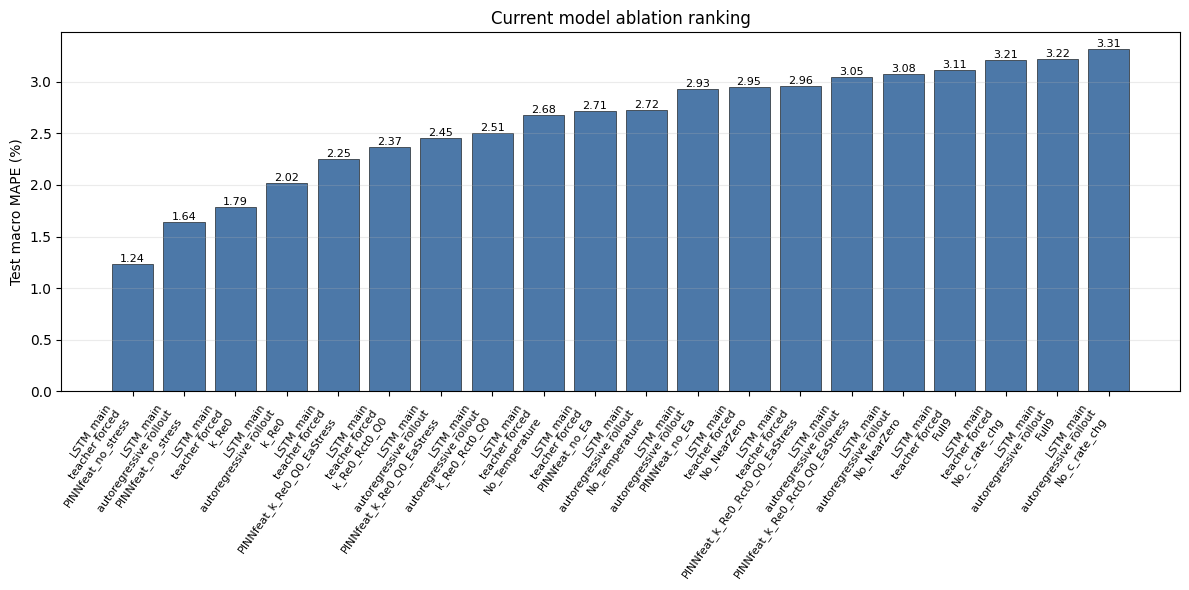

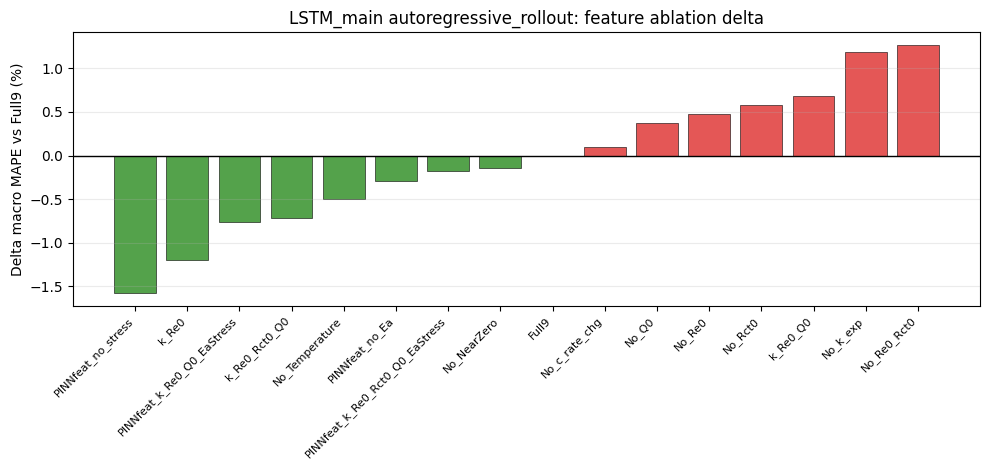

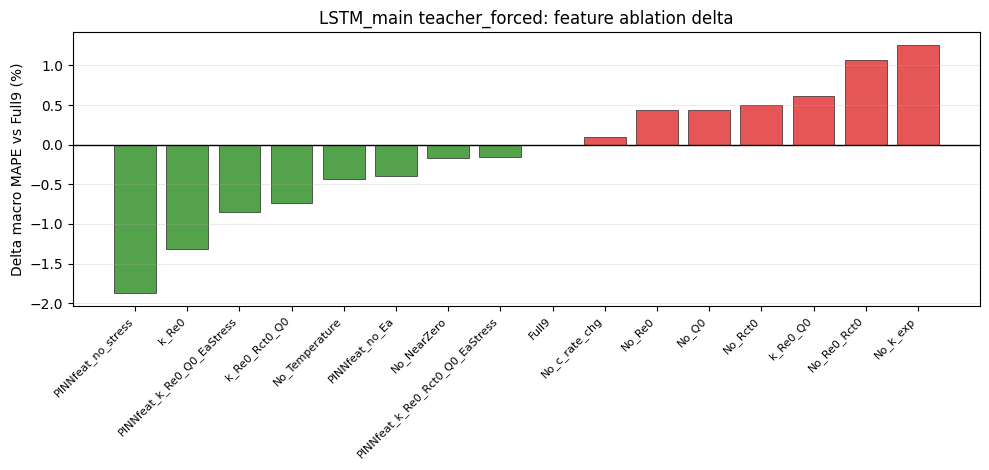

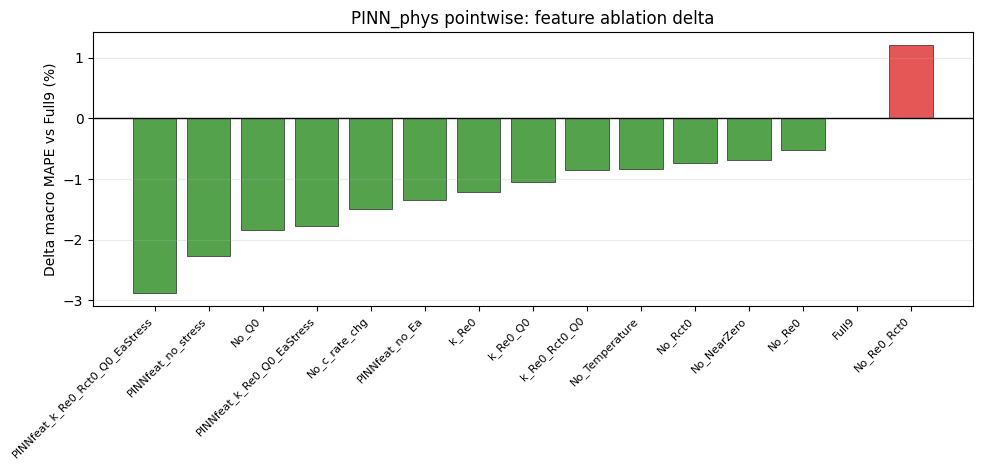

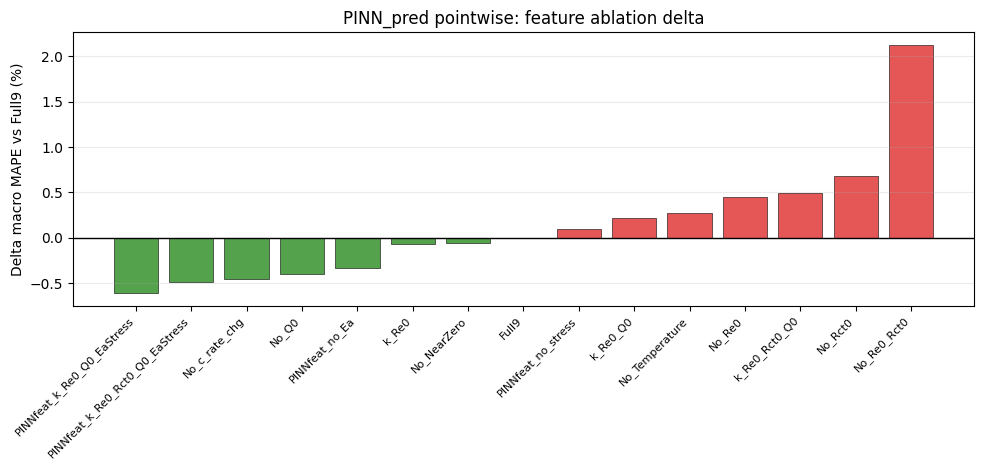

In [9]:
macro = metrics_df[metrics_df["target"] == "macro_avg"].copy()
baseline = macro[macro["variant"] == "Full9"][["model", "protocol", "MAPE"]].rename(columns={"MAPE": "Full9_MAPE"})
macro = macro.merge(baseline, on=["model", "protocol"], how="left")
macro["Delta_vs_Full9"] = macro["MAPE"] - macro["Full9_MAPE"]
macro = macro.sort_values(["model", "protocol", "MAPE"])
macro.to_csv(OUT_DIR / "phase1e_current_model_ablation_macro_summary.csv", index=False)
display(macro)

top = macro.sort_values("MAPE").head(20).copy()
top["label"] = top["model"] + "\n" + top["protocol"].str.replace("_", " ") + "\n" + top["variant"]
plt.figure(figsize=(12, 6))
plt.bar(range(len(top)), top["MAPE"], color="#4C78A8", edgecolor="black", linewidth=0.4)
plt.xticks(range(len(top)), top["label"], rotation=55, ha="right", fontsize=8)
plt.ylabel("Test macro MAPE (%)")
plt.title("Current model ablation ranking")
plt.grid(axis="y", alpha=0.25)
for i, v in enumerate(top["MAPE"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "phase1e_current_model_ablation_ranking.png", dpi=250, bbox_inches="tight")
plt.show()

for (model, protocol), grp in macro.groupby(["model", "protocol"]):
    g = grp.sort_values("Delta_vs_Full9")
    plt.figure(figsize=(10, 4.8))
    colors = ["#54A24B" if x <= 0 else "#E45756" for x in g["Delta_vs_Full9"]]
    plt.bar(g["variant"], g["Delta_vs_Full9"], color=colors, edgecolor="black", linewidth=0.4)
    plt.axhline(0, color="black", lw=1)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.ylabel("Delta macro MAPE vs Full9 (%)")
    plt.title(f"{model} {protocol}: feature ablation delta")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"phase1e_delta_{slugify(model)}_{slugify(protocol)}.png", dpi=220, bbox_inches="tight")
    plt.show()



## 9. Export



In [10]:
manifest = {
    "run_tag": RUN_TAG,
    "created_at": datetime.now().isoformat(),
    "run_fast": RUN_FAST,
    "seq_len": SEQ_LEN,
    "lstm_max_epochs": LSTM_MAX_EPOCHS,
    "pinn_max_epochs": PINN_MAX_EPOCHS,
    "ablation_variants": ABLATION_VARIANTS,
    "pinn_variants": PINN_VARIANTS,
    "notes": [
        "Luh & Blank only.",
        "Kirkaldy is not used here.",
        "LSTM teacher-forced and rollout are evaluated for each feature variant.",
        "PINN-feature hybrid rows are the sparse LSTM variants containing Ea_kJ_mol_mean and stress.",
        "PINN_pred and PINN_phys are pointwise ablations.",
    ],
}
(OUT_DIR / "phase1e_current_model_ablation_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in OUT_DIR.glob("*"):
        z.write(f, arcname=f.name)

print("Zip:", zip_path)
for f in sorted(OUT_DIR.glob("*")):
    print(" -", f.name)

try:
    from IPython.display import FileLink
    display(FileLink(str(zip_path)))
except Exception:
    pass


Zip: /kaggle/working/phase1e_current_model_ablation_20260625_091259.zip
 - phase1e_current_model_ablation_macro_summary.csv
 - phase1e_current_model_ablation_manifest.json
 - phase1e_current_model_ablation_metrics_raw.csv
 - phase1e_current_model_ablation_ranking.png
 - phase1e_current_model_ablation_training_history.csv
 - phase1e_delta_lstm_main_autoregressive_rollout.png
 - phase1e_delta_lstm_main_teacher_forced.png
 - phase1e_delta_pinn_phys_pointwise.png
 - phase1e_delta_pinn_pred_pointwise.png


/kaggle/working/phase1e_current_model_ablation_20260625_091259.zip